# **Word Embeddings**

The requirements for this stage of the analysis are:

1. Most similar words (Using Static Word Embedding) from the top occurring words (max of 3 words, from Term-Frequency Language Model).
2. PCA of the words from the top 3 words (from the Term-Frequency Language Model).
3. Application of a Hugging Face model to your dataset (BERT-based topic model, BERT-based Sentiment / Emotion model)

As such, I am going to apply similarly the processes used in the lecture and course notes on the preprocessed dataset, considering mostly the `cleaned text` attribute of reddit_cleaned.csv

In [64]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
import joblib
import pandas as pd

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [65]:
corpus = pd.read_csv("../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_title_topics.csv")
corpus.head()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",NaN,2025-07-07 11:40:47,NaN,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2


## **Bag of Words Model**

In [66]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

added_stopwords = [
    "sa", "na", "ng", "ang", "mga", "yung", "pa", "lang", "naman", "ba",
    "ko", "mo", "nila", "pero", "daw", "din", "rin", "kasi", "nga", "eh",
    "si", "ni", "kay", "para", "kung", "ay", "lahat", "wala", "may", "meron",
    "dapat", "talaga", "ano", "oo", "hindi", "diba", "sobrang", "super",
    "mas", "isa", "dalawa", "tatlo", "sen", "say", "ma", "make", "ako", "ka"
]

custom_stopwords = list(set(ENGLISH_STOP_WORDS).union(added_stopwords))

In [67]:
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    # stop_words=custom_stopwords
)

doc2vec_bow = bow_vectorizer.fit_transform(corpus['cleaned_text'])
doc2vec_bow = pd.DataFrame(doc2vec_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
doc2vec_bow.head()

# Save to file
doc2vec_bow.to_pickle('doc2vec_bow.pkl')

# Load from file
doc2vec_bow = pd.read_pickle('doc2vec_bow.pkl')

In [68]:
def top_n_grams(document, top_n=10):
  return document.sort_values(ascending=False).index[:top_n].tolist()

In [69]:
doc2vec_bow.apply(lambda document:
                  top_n_grams(document, top_n=5),
                  axis=1)

0        [sen, sen bam, blue ribbon, ribbon committee, ...
1                       [sen, agriculture, kiko, bam, dam]
2        [sen, ribbon, blue ribbon, blue, taloguingona ...
3         [sen, committee, blue, ribbon, ribbon committee]
4        [sen, blue ribbon, ribbon, ribbon committee, b...
                               ...                        
13166    [tie, deepen tie, infrastructure plan, japan d...
13167    [philippine japan, thats scary, deepen, deepen...
13168    [tie 15, partnership daijoubu, deepen, japan d...
13169    [deepen tie, theyre less, although, connection...
13170                        [ng, russia, sa, mga, ng mga]
Length: 13171, dtype: object

In [70]:
# Wordcloud using BoW and TF-IDF
def plot_wordcloud(data, title):
  wordcloud = WordCloud(
    width=800, height=400, background_color='white'
  ).generate_from_frequencies(data)
  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

sa              8430
na              8233
ng              6352
ang             5378
philippine      4132
agriculture     3976
mga             3720
yung            2777
pa              2549
lang            2387
may             2254
rice            1807
farmer          1710
ko              1673
go              1617
mo              1542
agricultural    1423
naman           1403
ba              1360
get             1277
dtype: int64


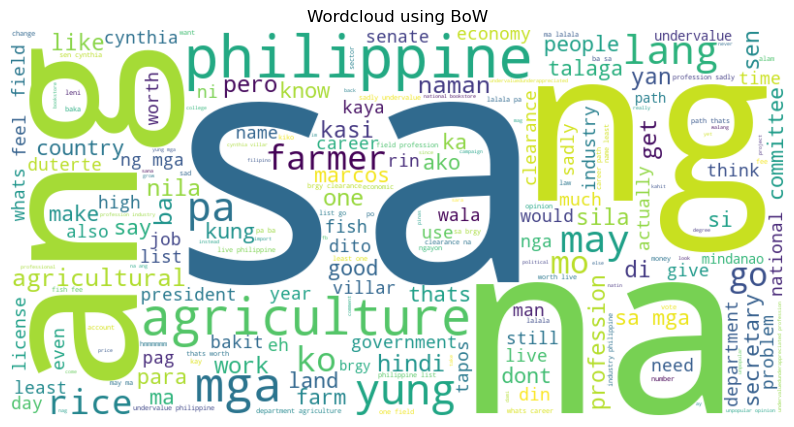

In [71]:
bow_frequencies = doc2vec_bow.sum(axis=0).sort_values(ascending=False)
print(bow_frequencies.head(20))
plot_wordcloud(bow_frequencies, 'Wordcloud using BoW')

## **Analysis based on this BoW (Including knowledge from Data Preprocessing and EDA Steps)**

I still need to find the working way to implement stop-words. It seems that the dataset is still ignoring the stop-words i had implemented.

But for the sake of analysis, we can ignore the stopwords and the top words based on frequency would be:
1. Philippine
2. Agriculture
3. Rice
4. Farmer
5. Agricultural

Which could mean based on what I understand is that there are frequent conversations pertaining to Rice Farming. And based as well on my knowledge on the field, Rice-Farming is the most controversial part of agriculture, followed by Fisheries and then vegetations.

This could mean a number of possible things:

- Polarized discussions on Rice Farming
- Frequent concerns of farmers stemming from keywords found on the set
    - Undervalued (possibly as a profession or as a means)
    - Government or Political platform issues regarding farmers/farming/rice/agriculture
    - Land concerns, previously mentioned in EDA "Cynthia Villar" is reknowned for abusing farmers.

# **Implementing Static Word Embeddings**

In [72]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [73]:
import gensim

In [74]:
corpus.head()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",NaN,2025-07-07 11:40:47,NaN,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2


In [75]:
# Tokenize the text
corpus['tokenized_text'] = corpus['cleaned_text'].apply(lambda x: x.split())

In [76]:
display(
  corpus['cleaned_text'].head()
)

display(
  corpus['tokenized_text'].head()
)

0    sen marcoleta hold blue ribbon committee sen b...
1    sen marcoleta hold blue ribbon committee sen b...
2    sen marcoleta hold blue ribbon committee sen b...
3    sen marcoleta hold blue ribbon committee sen b...
4    sen marcoleta hold blue ribbon committee sen b...
Name: cleaned_text, dtype: object

0    [sen, marcoleta, hold, blue, ribbon, committee...
1    [sen, marcoleta, hold, blue, ribbon, committee...
2    [sen, marcoleta, hold, blue, ribbon, committee...
3    [sen, marcoleta, hold, blue, ribbon, committee...
4    [sen, marcoleta, hold, blue, ribbon, committee...
Name: tokenized_text, dtype: object

In [77]:
model = gensim.models.Word2Vec(corpus['tokenized_text'],
                               vector_size=100,  # Dimension of the word vectors
                               min_count=1,    # Ignores all words with total frequency lower min_count
                               sg=0,           # Training algorithm: 0 for CBOW; 1 for Skip-gram
                               window=5,       # Maximum distance between the current & predicted word within a sentence
                               workers=4,      # Number of workers to use for training
                               epochs=10       # Number of iterations over the corpus
                               )

model.save('word2vec.model')

In [78]:
# Load the model
model = gensim.models.Word2Vec.load('word2vec.model')

# Get vectors from the model
vectors = model.wv

In [79]:
# Number of word vectors generated (columns)
len(vectors)

28803

In [80]:
# List of words / tokens sorted by most frequent
vectors.index_to_key
vectors.index_to_key[:20]  

['sa',
 'na',
 'ng',
 'ang',
 'philippine',
 'agriculture',
 'mga',
 'yung',
 'pa',
 'lang',
 'may',
 'rice',
 'farmer',
 'ko',
 'go',
 'mo',
 'agricultural',
 'naman',
 'ba',
 'get']

In [81]:
# The similarity method returns a score of how similar the vectors of two words are. 
# The closer the score is to 1, the higher the similarity. The closer to 0, the lower the similarity.
vectors.similarity('agriculture', 'philippine')

0.31555134

In [82]:

vectors.similarity('rice', 'philippine')

0.31714103

In [83]:

vectors.similarity('farmer', 'philippine')

0.33468235

In [84]:

vectors.similarity('rice', 'agriculture')

0.32484603

In [85]:
# The most_similar method returns words whose vectors are most similar to the given word.
vectors.most_similar('farmer', topn=15)

[('small', 0.7310801148414612),
 ('owner', 0.7297095656394958),
 ('distribute', 0.7009680271148682),
 ('middleman', 0.695594072341919),
 ('upgrade', 0.6934583783149719),
 ('interest', 0.685885488986969),
 ('lote', 0.6854245066642761),
 ('business', 0.6812301874160767),
 ('exportminded', 0.669015645980835),
 ('profit', 0.668049156665802),
 ('technology', 0.6652605533599854),
 ('instead', 0.6640419363975525),
 ('iresearch', 0.6589872241020203),
 ('profession9', 0.6579763889312744),
 ('farm', 0.654309868812561)]

In [86]:
# The most_similar method returns words whose vectors are most similar to the given word.
vectors.most_similar('villar', topn=15)

[('cynthia', 0.9412099123001099),
 ('hutaena', 0.8727320432662964),
 ('researchresearch', 0.8330898284912109),
 ('sen', 0.8327878713607788),
 ('villarmas', 0.8275367021560669),
 ('pak', 0.8266674876213074),
 ('nakakapanglata', 0.8167474865913391),
 ('villiar', 0.806524932384491),
 ('madame', 0.8046551942825317),
 ('aling', 0.8000209927558899),
 ('kamote', 0.7803799510002136),
 ('magagalit', 0.779513955116272),
 ('marcoleta', 0.7747496366500854),
 ('kalaunan', 0.7734145522117615),
 ('mince', 0.7714874148368835)]

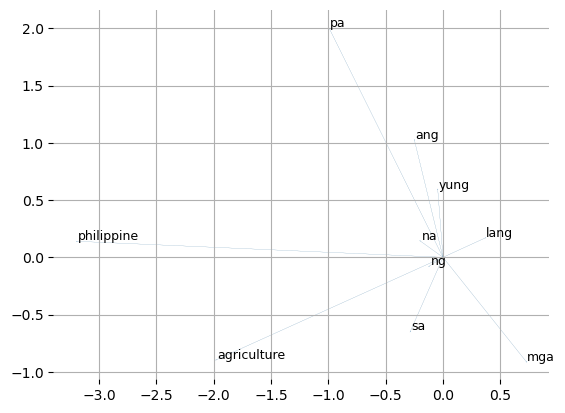

In [87]:
# Plot word vectors
def plot_vectors(vectors, words):
  # Create a figure and a 2D Axes
  fig, ax = plt.subplots()

  for word in words:
    # Get the vector for the word
    vector = vectors[word]

    # Plot the word near the arrow head
    ax.text(vector[0] + 0.01, vector[1] + 0.01, word, fontsize=9)
    # Plot the vector
    ax.arrow(
      0,                      # Start x
      0,                      # Start y
      vector[0],              # End x
      vector[1],              # End y
      # head_width=0.05,      # Arrow head width
      # head_length=0.1       # Arrow head length
      head_width=0.05 * 0.1,  # Arrow head width
      head_length=0.1 * 0.1,  # Arrow head length
      lw=0.01,                # Arrow line width
      # fc='r',                 # Arrow fill color
      # ec='r'                  # Arrow edge color
    )

  # Remove border around the plot
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.spines['left'].set_visible(False)

  plt.grid()

  # Display the plot
  plt.show()


plot_vectors(vectors, vectors.index_to_key[:10])

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [104]:
# Words most similar to "rice"
vectors.most_similar('rice', topn=5)
word_set1 = [word for word, score in vectors.most_similar('pogo', topn=5)]
word_set1

['nagaganap', 'batok', 'stance', 'secsi', 'wikipedia']

In [105]:
# Words most similar to 'agriculture'
vectors.most_similar('agriculture', topn=5)
word_set2 = [word for word, score in vectors.most_similar('scam', topn=5)]
word_set2

['therapeutic', 'hassle', 'allowance', 'agriculturepero', 'binhi']

In [106]:
words_to_viz = word_set1 + word_set2
words_to_viz

['nagaganap',
 'batok',
 'stance',
 'secsi',
 'wikipedia',
 'therapeutic',
 'hassle',
 'allowance',
 'agriculturepero',
 'binhi']

In [107]:
vecs_to_viz = [vectors[word] for word in words_to_viz]
vecs_to_viz

[array([-7.60885254e-02, -6.32874146e-02, -1.20160200e-01, -4.87730950e-02,
         4.16316055e-02, -3.05927563e-02,  3.13814916e-02,  1.05523281e-01,
         1.42535074e-02, -4.27388959e-02, -1.73997544e-02,  2.27621989e-03,
        -4.69203927e-02,  5.60973026e-02,  2.64962688e-02, -5.52630372e-05,
        -2.32454855e-02, -5.51220076e-03,  1.59842353e-02, -1.25450909e-01,
        -6.99550956e-02, -3.06111071e-02,  1.86770428e-02,  1.01441219e-02,
         4.97501083e-02, -4.40094322e-02, -2.57254131e-02, -5.91777340e-02,
         1.01921216e-01, -1.36517442e-03,  2.99177859e-02,  1.51713088e-01,
        -1.66751556e-02, -3.45922187e-02,  3.21878940e-02, -3.98202501e-02,
        -6.36087805e-02, -1.20036915e-01,  3.48423794e-02,  2.97584641e-03,
         2.28889547e-02, -8.44539627e-02, -2.30487008e-02, -2.85860691e-02,
         5.31472676e-02, -4.02065851e-02, -5.51107377e-02,  3.36374715e-02,
        -1.30328223e-01, -5.32689737e-03,  8.89679641e-02, -1.83785725e-02,
        -3.0

In [108]:
pca = PCA(n_components=2)
vecs_PCA = pca.fit_transform(vecs_to_viz)
vecs_PCA

array([[ 0.26220106, -0.06749756],
       [ 0.27701308, -0.05170857],
       [-0.75524552, -0.49543238],
       [ 0.4879121 ,  0.00513269],
       [ 0.06796522, -0.10042277],
       [ 0.45385893,  0.06502839],
       [-0.17136316,  0.14313687],
       [-1.1799475 ,  0.32942183],
       [ 0.38184083,  0.07566772],
       [ 0.17576495,  0.09667378]])

In [109]:
vecs_PCA_df = pd.DataFrame(columns=['word', 'association', 'PC1', 'PC2'])

for idx in range(len(words_to_viz)):
  word = words_to_viz[idx]
  association = 'agriculture' if word in word_set1 else 'rice'
  PC1 = vecs_PCA[idx, 0]
  PC2 = vecs_PCA[idx, 1]
  new_row = [word, association, PC1, PC2]

  vecs_PCA_df.loc[len(vecs_PCA_df)] = new_row

vecs_PCA_df

,word,association,PC1,PC2
0,nagaganap,agriculture,0.262201,-0.067498
1,batok,agriculture,0.277013,-0.051709
2,stance,agriculture,-0.755246,-0.495432
3,secsi,agriculture,0.487912,0.005133
4,wikipedia,agriculture,0.067965,-0.100423
5,therapeutic,rice,0.453859,0.065028
6,hassle,rice,-0.171363,0.143137
7,allowance,rice,-1.179947,0.329422
8,agriculturepero,rice,0.381841,0.075668
9,binhi,rice,0.175765,0.096674


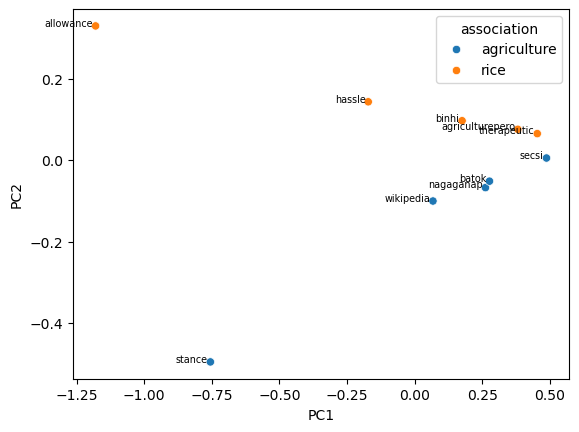

In [110]:
vecs_viz = sns.scatterplot(data=vecs_PCA_df, x='PC1', y='PC2', hue='association')
for idx in range(len(words_to_viz)):
  vecs_viz.text(vecs_PCA_df.PC1[idx] - 0.01, vecs_PCA_df.PC2[idx], vecs_PCA_df.word[idx], horizontalalignment='right',
                size='x-small', color='black', weight='light')
vecs_viz

plt.show()

In [112]:
def viz_associated_wordvecs(word1, word2, topn=5, model=vectors):
  word_set1 = [model.most_similar(word1, topn=topn)[idx][0] for idx in range(topn)]
  word_set2 = [model.most_similar(word2, topn=topn)[idx][0] for idx in range(topn)]
  words_to_viz = word_set1 + word_set2
  vecs_to_viz = [model[word] for word in words_to_viz]

  pca = PCA(n_components=2)
  vecs_PCA = pca.fit_transform(vecs_to_viz)
  vecs_PCA_df = pd.DataFrame(columns=['word', 'association', 'PC1', 'PC2'])

  for idx in range(len(words_to_viz)):
    word = words_to_viz[idx]
    association = word1 if word in word_set1 else word2
    PC1 = vecs_PCA[idx, 0]
    PC2 = vecs_PCA[idx, 1]
    new_row = [word, association, PC1, PC2]
    vecs_PCA_df.loc[len(vecs_PCA_df)] = new_row

  vecs_viz = sns.scatterplot(data=vecs_PCA_df, x='PC1', y='PC2', hue='association')

  for idx in range(len(words_to_viz)):
    vecs_viz.text(vecs_PCA_df.PC1[idx] - 0.01, vecs_PCA_df.PC2[idx], vecs_PCA_df.word[idx], horizontalalignment='right',
                  size='x-small', color='black', weight='light')
  return vecs_PCA_df

,word,association,PC1,PC2
0,lofty,rice,-2.235988,0.353094
1,import,rice,7.314971,3.817702
2,sugar,rice,1.874633,-0.946266
3,food,rice,6.576227,-3.648502
4,declaration,rice,-2.293927,0.259533
5,nofishing,farm,-2.458267,0.221757
6,courserequirement,farm,-2.506838,0.208552
7,realstate,farm,-2.304217,0.160157
8,unproductive,farm,-2.302855,0.072071
9,vertical,farm,-1.663740,-0.498098


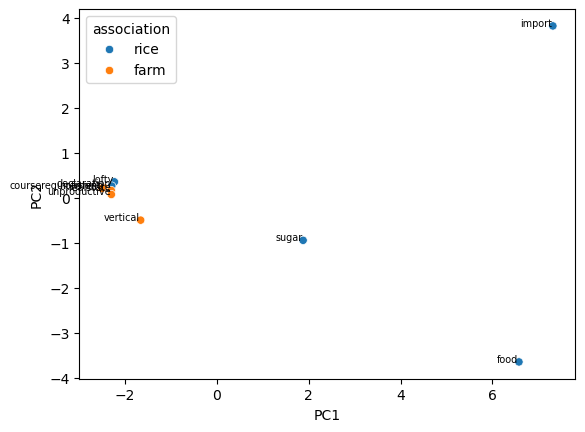

In [113]:
viz_associated_wordvecs('rice', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,astro,philippine,-0.248406,0.057467
1,flexible,philippine,-0.320723,-0.183267
2,psychometricians,philippine,-0.397852,-0.593749
3,doubtful,philippine,-0.345656,0.116810
4,mabibuild,philippine,-0.288705,0.174375
5,nofishing,farm,-0.155226,0.189472
6,courserequirement,farm,-0.135191,0.204787
7,realstate,farm,0.109243,0.078633
8,unproductive,farm,0.055805,0.038672
9,vertical,farm,1.726711,-0.083199


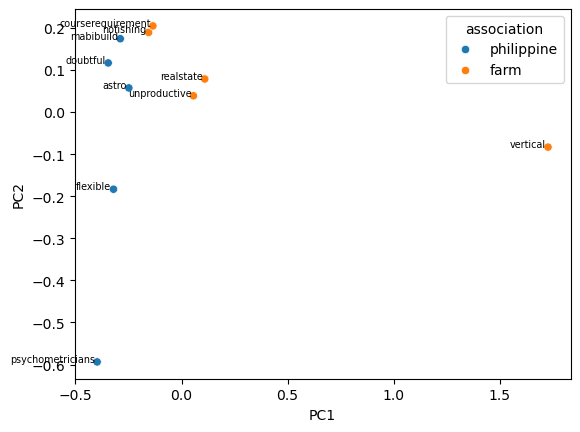

In [114]:
viz_associated_wordvecs('philippine', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,cynthia,villar,-8.867037,4.838144
1,hutaena,villar,3.953047,-0.056458
2,researchresearch,villar,-4.254507,0.347153
3,sen,villar,-14.276992,-3.543611
4,villarmas,villar,3.894951,-0.060071
5,nofishing,farm,4.086772,-0.167815
6,courserequirement,farm,4.054443,-0.169358
7,realstate,farm,4.025865,-0.192252
8,unproductive,farm,3.876080,-0.323113
9,vertical,farm,3.507378,-0.672618


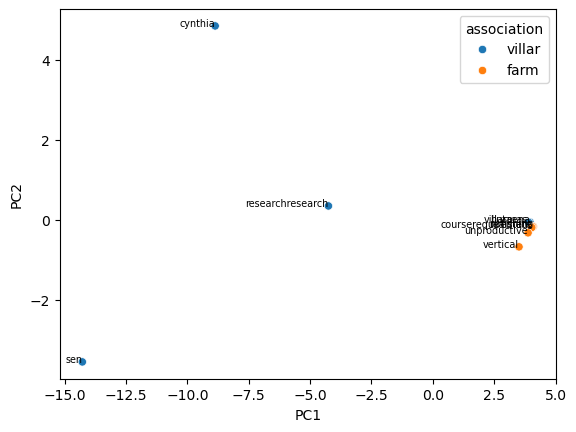

In [115]:
viz_associated_wordvecs('villar', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,undervalue,profession,7.987993,-0.473360
1,sadly,profession,6.382599,0.530776
2,undervaluedunderappreciated,profession,5.896666,-1.306206
3,art,profession,-1.741085,-3.289690
4,field,profession,2.739336,-0.859560
5,small,farmer,-3.259603,5.266201
6,owner,farmer,-5.085117,-1.926696
7,distribute,farmer,-2.269841,7.528468
8,middleman,farmer,-5.287187,-2.089686
9,upgrade,farmer,-5.363761,-3.380247


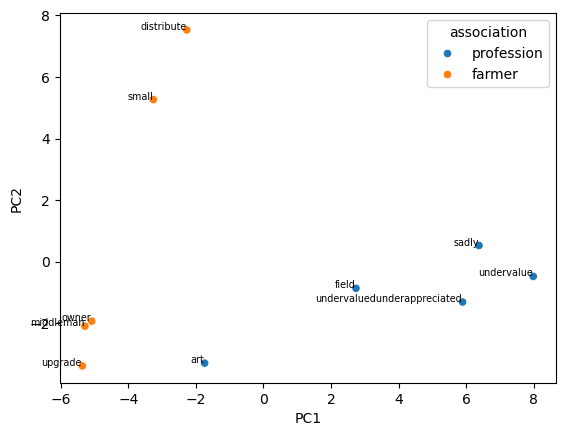

In [118]:
viz_associated_wordvecs('profession', 'farmer', topn=5, model=vectors)

## **Short Analysis for Static Word Embeddings and PCA**

Looking at these graphical representation (PCA) of Static Word Embeddings, it looks like Agriculture and Philippines does not seem to be aligned.

Despite being geographically advantageous as a agricultural country, based on these embeddings it seems that a lot of sentiments regarding agriculture is the fact that agriculture is undervalued. Historically, this probably stems from the lack of governmental support for our agriculture, or, could be an on-going trend especially that 'tech' or 'med' is becoming the hit profession, which causes stereotyping when it comes to agriculture or farming, making it undervalued.

However, this could also stem from the fact that the dataset may be heavily populated with tagalog words, and the methods applied may be inefficient (could probably require fine-tuning for tagalog-lexicon?)

# **Large Word Embeddings**

In [127]:
%pip install transformers triton

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement triton (from versions: none)
ERROR: No matching distribution found for triton


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from tqdm import tqdm
tqdm.pandas()

In [125]:
corpus[["created_utc","post_title","cleaned_text"]].head()

,created_utc,post_title,cleaned_text
0,2025-07-07 11:40:47,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
1,2025-07-07 12:38:47,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
2,2025-07-07 12:21:50,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
3,2025-07-07 11:51:43,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
4,2025-07-07 12:46:06,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...


In [ ]:
from transformers import pipeline

# https://huggingface.co/tabularisai/multilingual-sentiment-analysis

# @misc{tabularisai_2025,
#     author       = { tabularisai and Samuel Gyamfi and Vadim Borisov and Richard H. Schreiber },
#     title        = { multilingual-sentiment-analysis (Revision 69afb83) },
#     year         = 2025,
#     url          = { https://huggingface.co/tabularisai/multilingual-sentiment-analysis },
#     doi          = { 10.57967/hf/5968 },
#     publisher    = { Hugging Face }
# }

# Load the classification pipeline with the specified model
pipe = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis")

# Classify a new sentence
sentence = "I love this product! It's amazing and works perfectly."
result = pipe(sentence)

# Print the result
print(result)


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

C:\Users\Uwie\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Uwie\.cache\huggingface\hub\models--tabularisai--multilingual-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regul

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[{'label': 'Very Positive', 'score': 0.5586304068565369}]
